# Deep Learning

This notebook uses an Artificial Neural Network (ANN) to classify music into four emotion classes based on its audio features.

The neural network is compared with the traditional machine learning models developed previously.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/processed/moodify_clean.csv")

X = df.drop(columns=["labels"])
y = df["labels"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (276260, 10)
y shape: (276260,)


### Train/ test split + scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train_scaled.shape)
print("Test data:", X_test_scaled.shape)

Training data: (221008, 10)
Test data: (55252, 10)


## Artificial Neural Network

A feed-forward Artificial Neural Network is used to model non-linear relationships between the audio features and the four emotion classes.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

ann_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    
    Dense(64, activation="relu"),
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    Dropout(0.2),
    
    Dense(4, activation="softmax")
])

ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,916 (11.39 KB)

 Trainable params: 2,916 (11.39 KB)

 Non-trainable params: 0 (0.00 B)

**Early Stopping:** Training is set to a maximum of 30 epochs. Early Stopping monitors the validation loss and stops training if it does not improve for three consecutive epochs, restoring the weights from the best-performing epoch.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7937 - loss: 0.5082 - val_accuracy: 0.8514 - val_loss: 0.3565
Epoch 2/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8434 - loss: 0.3833 - val_accuracy: 0.8636 - val_loss: 0.3236
Epoch 3/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8534 - loss: 0.3577 - val_accuracy: 0.8712 - val_loss: 0.3073
Epoch 4/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8606 - loss: 0.3394 - val_accuracy: 0.8757 - val_loss: 0.2954
Epoch 5/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8636 - loss: 0.3279 - val_accuracy: 0.8788 - val_loss: 0.2856
Epoch 6/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8676 - loss: 0.3183 - val_accuracy: 0.8814 - val_loss: 0.2785
Epoch 7/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8697 - loss: 0.3109 - val_accuracy: 0.8835 - val_loss: 0.2725
Epoch 8/30
691/691 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8726 - loss: 0.3053 - val_accuracy: 0.

**Model architecture:** The ANN consists of two hidden layers with 64 and 32 neurons using ReLU activation. Dropout (20%) is applied after each hidden layer to reduce the risk of overfitting. The output layer contains four neurons with softmax activation, corresponding to the four emotion classes.

The model uses the Adam optimizer and sparse categorical crossentropy as the loss function for multi-class classification.

In [ ]:
test_loss, test_accuracy = ann_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"ANN Test Accuracy: {test_accuracy:.4f}")
print(f"ANN Test Loss: {test_loss:.4f}")

ANN Test Accuracy: 0.9002
ANN Test Loss: 0.2363


In [ ]:
ann_probabilities = ann_model.predict(X_test_scaled, verbose=0)
ann_predictions = np.argmax(ann_probabilities, axis=1)

print(
    classification_report(
        y_test,
        ann_predictions,
        target_names=["Sad", "Happy", "Energetic", "Calm"]
    )
)

              precision    recall  f1-score   support

         Sad       0.91      0.91      0.91     16326
       Happy       0.88      0.90      0.89     21145
   Energetic       0.88      0.82      0.85      9343
        Calm       0.96      0.96      0.96      8438

    accuracy                           0.90     55252
   macro avg       0.91      0.90      0.90     55252
weighted avg       0.90      0.90      0.90     55252



**Result:** The ANN achieved 90.02% test accuracy, outperforming Logistic Regression (83.70%) but performing below Random Forest (93.99%) and XGBoost (96.40%).

Calm remained the easiest emotion to classify (F1 = 0.96), while Energetic remained the most difficult (F1 = 0.85). This is consistent with the previous machine learning results, where Energetic was frequently confused with Happy.

The results also demonstrate that a more complex deep learning model does not necessarily outperform traditional machine learning methods. For this structured tabular dataset, the tree-based ensemble models were more effective.

---

### Training History

The training and validation curves are examined to evaluate how the ANN learned over time and whether signs of overfitting occurred.

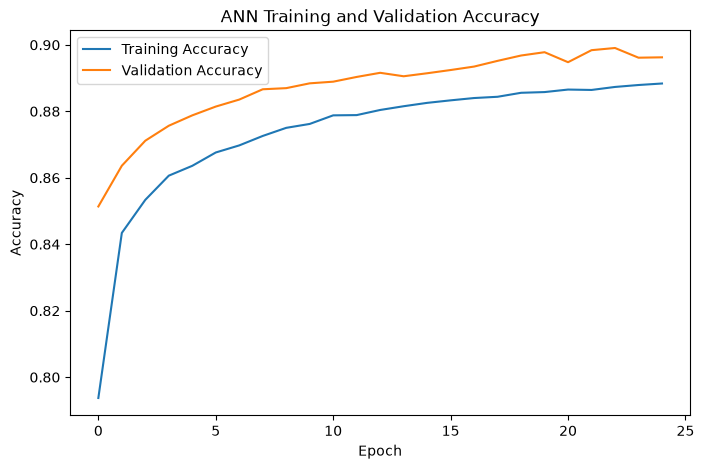

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.legend()
plt.show()

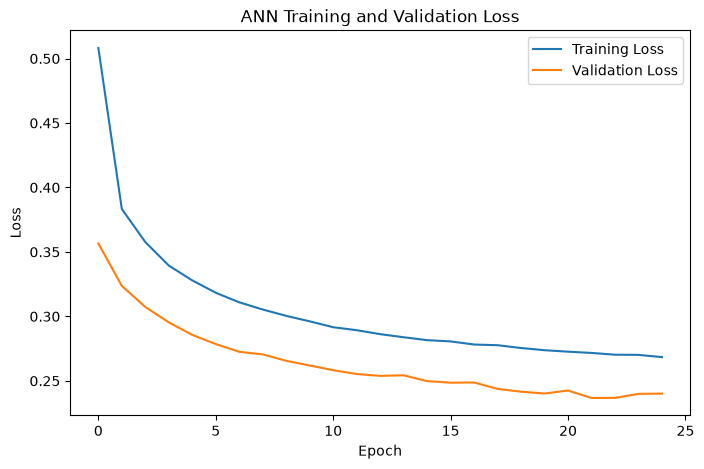

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.show()

### ANN Confusion Matrix

The normalized confusion matrix shows how the ANN performs for each emotion class and which emotions are most frequently confused.

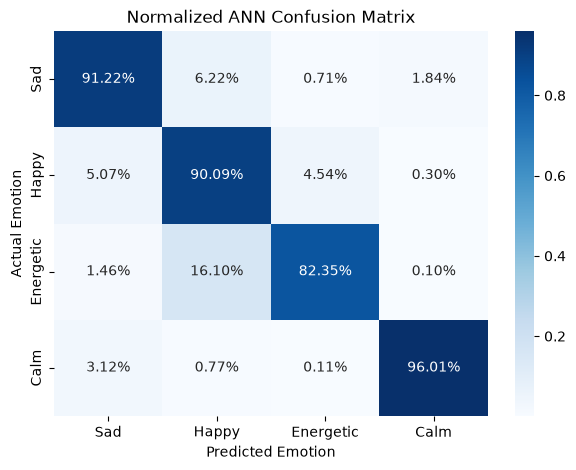

In [ ]:
ann_cm = confusion_matrix(
    y_test,
    ann_predictions,
    normalize="true"
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    ann_cm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=["Sad", "Happy", "Energetic", "Calm"],
    yticklabels=["Sad", "Happy", "Energetic", "Calm"]
)

plt.title("Normalized ANN Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

**Interpretation:** The training and validation curves show stable learning throughout the training process. Both accuracy curves improve while the loss curves decrease, with no clear signs of overfitting. Validation performance remains slightly better than training performance, which can be explained by Dropout being active during training but disabled during validation.

The confusion matrix shows that Calm is the easiest emotion for the ANN to classify, with 96.01% correctly predicted. Energetic remains the most difficult class at 82.35%, with 16.10% of Energetic tracks incorrectly classified as Happy. This follows the same pattern observed with the traditional machine learning models, although XGBoost handled the overlap between Energetic and Happy considerably better.

---

## Deep Learning Summary

The ANN achieved a test accuracy of 90.02%. It outperformed Logistic Regression (83.70%) but did not reach the performance of Random Forest (93.99%) or XGBoost (96.40%).

The model learned consistently without clear signs of overfitting. As in the previous models, Calm was the easiest emotion to classify, while Energetic was the most difficult and was primarily confused with Happy.

Overall, the results show that the ANN can successfully learn non-linear relationships between the audio features and emotion classes. However, for this structured tabular dataset, the tree-based ensemble models were more effective, with XGBoost achieving the best overall performance.